<a href="https://colab.research.google.com/github/sjohn214/Colab-Repos/blob/MNIST/Hands_on_mnist_digit_classification_ex_SLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# I) IMPORT REQUIRED LIBRARIES

#### Import required Tensorflow and Keras Libraries. Note: these libraries are already installed for you as part of Google Collab. However, they must be imported in order for your program or code to use them for NN models.



In [3]:
# Import libraries

import tensorflow as tf
import numpy as np
from tensorflow import keras


In [4]:
# Defining Neural Net and Training Parameters

EPOCHS_20 = 20 # Number of EPOCHS
BATCH_SIZE =128 # Batch size determines how many images will be used in each batch to train the NN Model

VERBOSE = 1 # Detailed Log about the Training Process of the NN Model

NB_CLASSES = 10 # Training to classify digits into one of the 10 classes and the classes are 0, 1, 2, 3, 4, 5, 6, 7, 8, and 9

VALIDATION_SPLIT =0.2 # How much training data is kept aside for validation

# I) IMPORT MNIST DATASET FROM KERAS LIBRARY

In [5]:
# Loading MNIST Dataset using the Keras Library

mnist = keras.datasets.mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
# train_images has 60000 rows of 28 X 28 values of gray scal images of digits 0, 1, 2, 3, 4, 5, 6, 7, 8, and 9
# We are going to fetch 784 train_images to 60000 rows by 784 : Note - 28 X 28 is 784

train_images = train_images.reshape(60000, 784)
test_images = test_images.reshape(10000, 784) # Test dataset consists of 10000 digits

train_images = train_images.astype('float32') # Convert pixel values from uint8 to float32
test_images = test_images.astype('float32')

train_images /=255
test_images /=255

print (train_images.shape[0], 'train samples')
print (test_images.shape[0], 'test samples')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
60000 train samples
10000 test samples


# ONE-HOT ENCODING OF THE TRAIN AND TEST LABELS REQUIRED

In [6]:
# Add ONE-HOT ENCODING Required

train_labels = keras.utils.to_categorical(train_labels, NB_CLASSES)
test_labels = keras.utils.to_categorical(test_labels, NB_CLASSES)

### Train Labels Array with ONE-HOT Encoding

In [7]:
train_labels

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]])

In [8]:
train_labels[4]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])

In [9]:
train_labels.shape

(60000, 10)

### Test Labels Array with ONE-HOT Encoding

In [10]:
test_labels

array([[0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [11]:
test_labels.shape

(10000, 10)

In [12]:
test_labels[14]

array([0., 1., 0., 0., 0., 0., 0., 0., 0., 0.])

In [13]:
test_labels[3001]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])

# III) VISUALIZING NEURAL NETWORK LAYERS AND INTERCONNECTION ACROSS LAYERS
### IV) Visualizing a neural network with 784 input layer and 10 neuron hidden_layer and 10 neuron output_layer

In [15]:
# Build the NN model to classify 10 handwritten digits
# Use Sequential Model - the simplest form of NN in Keras

model = tf.keras.models.Sequential() # Defining the NN model using the sequential() option - will discuss various options later
model.add(keras.layers.Dense(784, activation='relu')) # adding the input layer with 784
model.add(keras.layers.Dense(10, activation='relu')) # adding the hidden layer of 512 neurons
model.add(keras.layers.Dense(10, activation='softmax'))

# V) ADD OPTIMIZER TO GUIDE NN MODEL TRAINING FOR MOR ACCURACY

In [16]:
# Adding Optimizer - there are several choices
# categorical_crossentropy means multiclass logarithmic loss. Compares the distribution of the predictions with the true distribution.
# True class in one HOT vector and closer the models output to that vector

model.compile(optimizer='SGD',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# VI) TRAIN THE NN MODEL USING TRAINING DATA SET AND SET ASIDE 20 PERCENT TRAINING DATA FOR VALIDATION TESTING

In [17]:
# Training the Model

model.fit(train_images, train_labels,
          batch_size=BATCH_SIZE, epochs = EPOCHS_20,
          verbose = VERBOSE, validation_split = VALIDATION_SPLIT)

print(model.summary())

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.6256 - loss: 1.3976 - val_accuracy: 0.8369 - val_loss: 0.7364
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8481 - loss: 0.6100 - val_accuracy: 0.8768 - val_loss: 0.4769
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8779 - loss: 0.4600 - val_accuracy: 0.8924 - val_loss: 0.3960
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8933 - loss: 0.3955 - val_accuracy: 0.9032 - val_loss: 0.3502
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9021 - loss: 0.3563 - val_accuracy: 0.9085 - val_loss: 0.3234
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9099 - loss: 0.3288 - val_accuracy: 0.9148 - val_loss: 0.3030
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9149 - loss: 0.3075 - val_accuracy: 0.9195 - val_loss: 0.2848
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9203 - loss: 0.2895 - val_accu

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (128, 784)             │       615,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (128, 10)              │         7,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (128, 10)              │           110 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 623,402 (2.38 MB)

 Trainable params: 623,400 (2.38 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

None


# VII) EVALUATION OF TRAINED NN MODEL USING TEST DATA SET AND TEST LABELS

In [18]:
# Evaluate the trained NN Model

test_loss, test_acc = model.evaluate(test_images, test_labels)

print('Test accuracy:', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9487 - loss: 0.1748
Test accuracy: 0.9487000107765198


# VIII) PREDICTION USING THE TRAINED NN MODEL USING TEST IMAGES NOT SEEN BY THE MODEL BEFORE

In [19]:
# Prediction using training NN model

test_digits = test_images[0:20]
predictions = model.predict(test_digits)
predictions[7]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


array([3.7881878e-04, 3.9184270e-03, 5.8576884e-04, 6.0859513e-03,
       9.0016536e-03, 1.4756129e-03, 1.0823102e-03, 3.8027368e-02,
       9.6724937e-03, 9.2977166e-01], dtype=float32)

In [22]:
predictions[7].argmax()

np.int64(9)

In [23]:
predictions[7][9]

np.float32(0.92977166)

# VIIII) Now to visualize the predicted digit


In [27]:
test_digits.shape # current shape of the test_digits array

(20, 784)

# Reshapeing test_digits array from (20, 784) to (20, 28, 28) is critical to display the predicted image using pyplot

In [28]:
test_digits = test_digits.reshape(20,28,28)

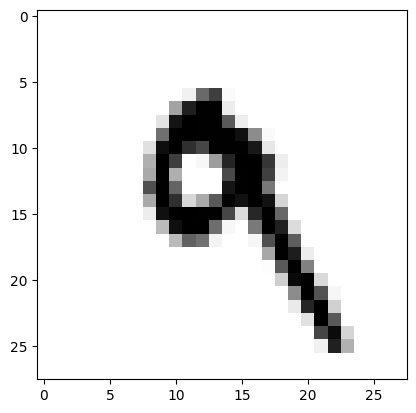

In [29]:
import matplotlib.pyplot as plt
digit = test_digits[7]
plt.imshow(digit, cmap=plt.cm.binary)
plt.show()